# 01 - ffNN baseline profesor

Notebook base inspirado en `ffNN_example.ipynb`. El objetivo es tener una primera red feed-forward sencilla, leyendo las etiquetas desde `xview_ann_train.json`, y dejar una estructura clara para entender cada parte antes de pasar a modelos mas complejos.


## Librerias y configuracion


In [2]:
import json
import math
import uuid
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
import rasterio
from rasterio.errors import NotGeoreferencedWarning
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))

2026-05-26 08:27:49.292168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779784069.670368      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779784069.777443      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779784070.675734      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779784070.675776      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779784070.675780      57 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Kaggle-only: busca automaticamente xview_ann_train.json dentro de /kaggle/input.
# No dependemos del nombre exacto del Dataset en Kaggle.
KAGGLE_INPUT_DIR = Path('/kaggle/input')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError(
        'No existe /kaggle/input. Ejecuta este notebook en Kaggle y anade el dataset xview_recognition como Input.'
    )

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json dentro de /kaggle/input. '
        f'Inputs disponibles: {available_inputs}. '
        'Comprueba que has anadido el dataset xview_recognition al notebook.'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'
WORKDIR = Path('/kaggle/working')

print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


DATA_ROOT: /kaggle/input/datasets/eccvdl/xview-recognition
ANN_JSON: /kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


## Datos


### Lectura del JSON


In [4]:
class GenericObject:
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category = -1
        self.score = -1

class GenericImage:
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])
        self.objects = []

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)


In [5]:
def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
    with rasterio.open(DATA_ROOT / filename, 'r') as src_raster:
        img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=src_raster.profile['dtype'])
        for band in range(src_raster.count):
            img[:, :, band] = src_raster.read(band + 1)
    return img


In [6]:
with open(ANN_JSON, 'r', encoding='utf-8') as ifs:
    json_data = json.load(ifs)

categories = {
    int(k): v['name']
    for k, v in sorted(json_data['categories'].items(), key=lambda item: int(item[0]))
}
category_names = list(categories.values())
category_to_idx = {name: idx for idx, name in categories.items()}

print('Categorias:')
print(categories)
print('Imagenes en JSON:', len(json_data['images']))
print('Anotaciones en JSON:', len(json_data['annotations']))


Categorias:
{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
Imagenes en JSON: 18746
Anotaciones en JSON: 18746


In [7]:
counts = dict.fromkeys(category_names, 0)
anns = []

for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])

    obj = GenericObject()
    obj.bb = tuple(int(x) for x in json_ann['bbox'])
    obj.category = json_ann['category_id']

    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)

print('Numero de imagenes train:', len(anns))
print('Distribucion por clase:')
for name, count in counts.items():
    print(f'{name:20s}: {count}')


Numero de imagenes train: 18746
Distribucion por clase:
Cargo plane         : 635
Small car           : 3324
Bus                 : 1768
Truck               : 2210
Motorboat           : 1069
Fishing vessel      : 706
Dump truck          : 1236
Excavator           : 789
Building            : 3594
Helipad             : 111
Storage tank        : 1469
Shipping container  : 1523
Pylon               : 312


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype: uint8
Min / Max: 0 86
Etiqueta: Building
Indice de clase: 8
Bounding box: (0, 0, 224, 224)
Primeros pixeles del array:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]


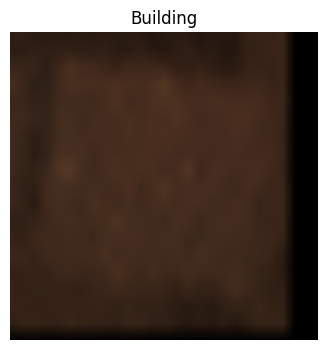

In [8]:
sample_ann = anns[0]
sample_obj = sample_ann.objects[0]
sample_img = load_geoimage(sample_ann.filename)

print('Filename:', sample_ann.filename)
print('Shape:', sample_img.shape)
print('Dtype:', sample_img.dtype)
print('Min / Max:', sample_img.min(), sample_img.max())
print('Etiqueta:', sample_obj.category)
print('Indice de clase:', category_to_idx[sample_obj.category])
print('Bounding box:', sample_obj.bb)
print('Primeros pixeles del array:')
print(sample_img[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(sample_obj.category)
plt.axis('off')
plt.show()


### Split train/valid


In [9]:
anns_train, anns_valid = train_test_split(
    anns,
    test_size=0.1,
    random_state=1,
    shuffle=True,
)

print('Number of training images:', len(anns_train))
print('Number of validation images:', len(anns_valid))


Number of training images: 16871
Number of validation images: 1875


## Red


### Arquitectura y summary


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Flatten(input_shape=(224, 224, 3)),
    Activation('relu'),
    Dense(len(categories)),
    Activation('softmax'),
])

opt = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1779784143.941396      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779784143.947570      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 13)             │     1,956,877 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,956,877 (7.46 MB)

 Trainable params: 1,956,877 (7.46 MB)

 Non-trainable params: 0 (0.00 B)

### Callbacks


In [11]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

MODEL_PATH = WORKDIR / '01_ffnn_baseline_profesor.keras'
callbacks = [
    ModelCheckpoint(str(MODEL_PATH), monitor='val_accuracy', verbose=1, save_best_only=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=40, verbose=1),
    TerminateOnNaN(),
]

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: /kaggle/working/01_ffnn_baseline_profesor.keras


### Entrenamiento


In [12]:
def generator_images(objs, batch_size, do_shuffle=False):
    while True:
        if do_shuffle:
            np.random.shuffle(objs)
        groups = [objs[i:i + batch_size] for i in range(0, len(objs), batch_size)]
        for group in groups:
            images, labels = [], []
            for filename, obj in group:
                images.append(load_geoimage(filename))
                probabilities = np.zeros(len(categories), dtype=np.float32)
                probabilities[category_to_idx[obj.category]] = 1.0
                labels.append(probabilities)
            images = np.array(images).astype(np.float32)
            labels = np.array(labels).astype(np.float32)
            yield images, labels


In [13]:
objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

batch_size = 16
train_generator = generator_images(objs_train, batch_size, do_shuffle=True)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)

print('Objetos train:', len(objs_train))
print('Objetos valid:', len(objs_valid))

Objetos train: 16871
Objetos valid: 1875


In [14]:
epochs = 20
train_steps = math.ceil(len(objs_train) / batch_size)
valid_steps = math.ceil(len(objs_valid) / batch_size)

history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1,
)

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)

Epoch 1/20


I0000 00:00:1779784148.887669     130 service.cc:152] XLA service 0x7ea99c107490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779784148.887736     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779784148.887743     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779784149.205007     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1055 ━━━━━━━━━━━━━━━━━━━━ 45:03 3s/step - accuracy: 0.0625 - loss: 177.6409

I0000 00:00:1779784150.697606     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2311 - loss: 4513.4858
Epoch 1: val_accuracy improved from -inf to 0.31147, saving model to /kaggle/working/01_ffnn_baseline_profesor.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 1396s 1s/step - accuracy: 0.2311 - loss: 4512.7437 - val_accuracy: 0.3115 - val_loss: 3318.4033 - learning_rate: 0.0010
Epoch 2/20
1054/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2986 - loss: 3417.4883
Epoch 2: val_accuracy did not improve from 0.31147
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 115s 109ms/step - accuracy: 0.2986 - loss: 3417.6074 - val_accuracy: 0.2635 - val_loss: 4328.2129 - learning_rate: 0.0010
Epoch 3/20
1054/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3230 - loss: 3462.7756
Epoch 3: val_accuracy did not improve from 0.31147
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 103s 97ms/step - accuracy: 0.3229 - loss: 3462.9165 - val_accuracy: 0.2992 - val_loss: 4246.7915 - learning_rate: 0.0010
Epoch 4/20
1054/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accur

## Resultados


### Graficas de entrenamiento


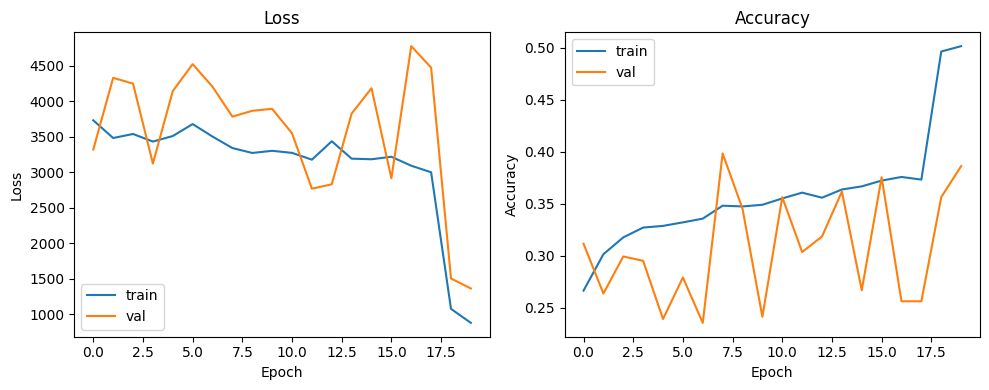

In [15]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Matriz de confusion


In [16]:
model.load_weights(MODEL_PATH)
y_true, y_pred = [], []

for ann in anns_valid:
    image = load_geoimage(ann.filename)
    predictions = model.predict(np.expand_dims(image, 0), verbose=0)
    pred_category = category_names[int(np.argmax(predictions))]
    for obj_true in ann.objects:
        y_true.append(obj_true.category)
        y_pred.append(pred_category)

cm = confusion_matrix(y_true, y_pred, labels=category_names)


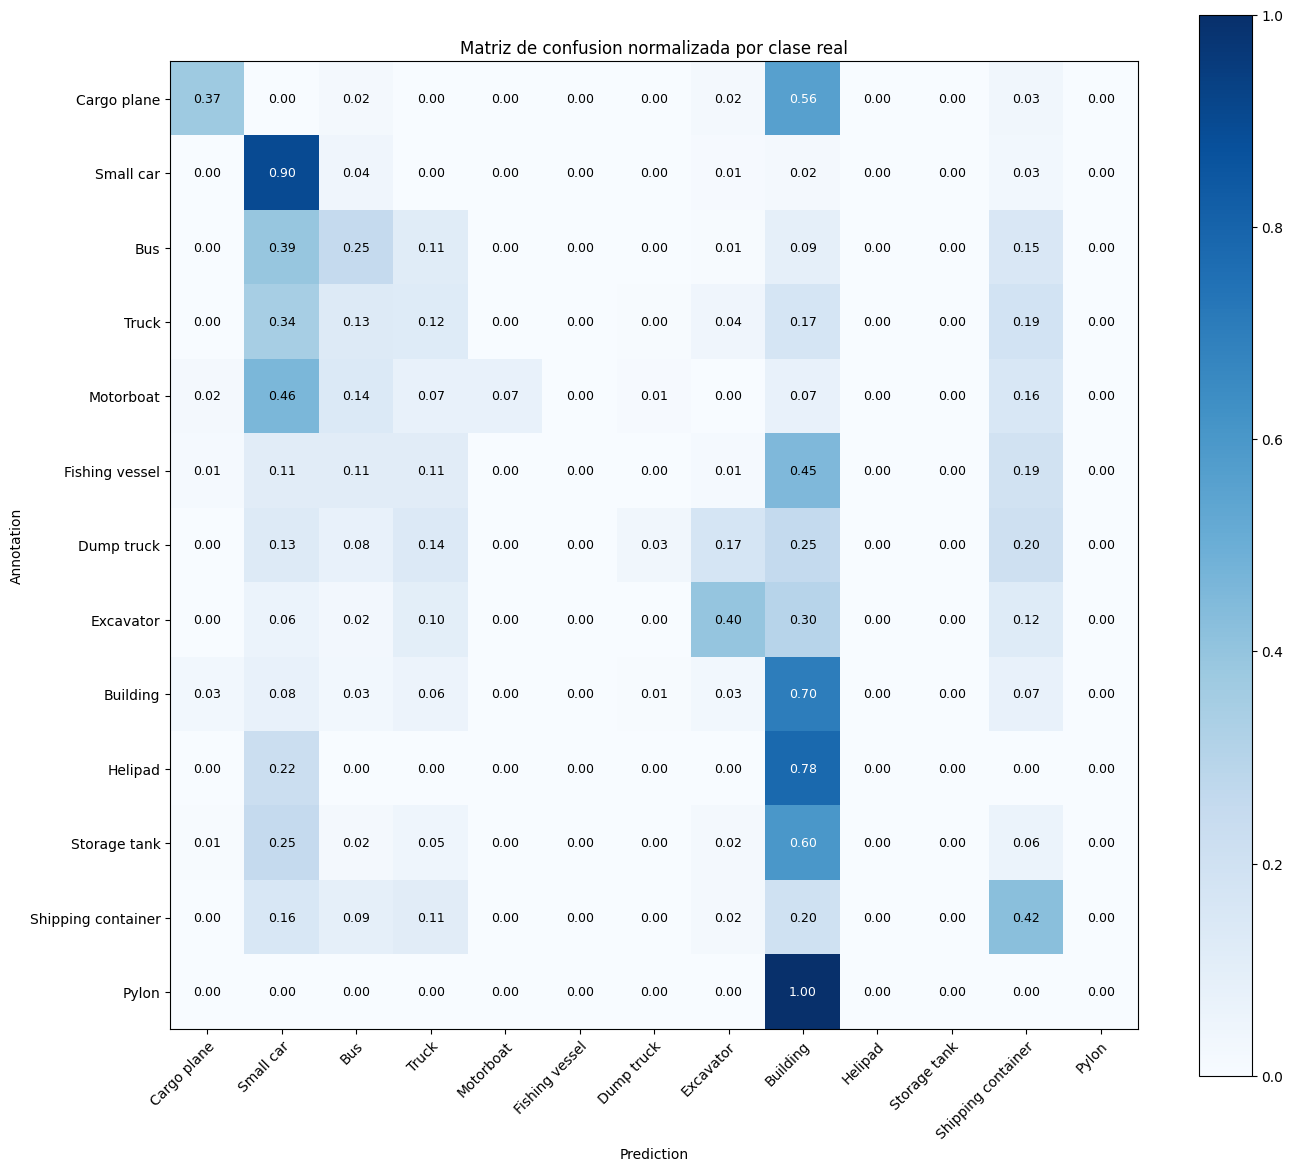

In [17]:
def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(
                j,
                i,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if value > threshold else 'black',
                fontsize=9,
            )

    ax.set_title('Matriz de confusion normalizada por clase real')
    fig.tight_layout()
    plt.show()

draw_confusion_matrix_percent(cm, category_names)


### Metricas por clase


In [18]:
correct = np.diag(cm).astype(float)
total_true = np.sum(cm, axis=1).astype(float)
total_pred = np.sum(cm, axis=0).astype(float)

print('Mean Accuracy: %.3f%%' % (np.sum(correct) / np.sum(total_true) * 100))
print('Mean Recall: %.3f%%' % ((correct / np.maximum(total_true, np.finfo(np.float64).eps)).mean() * 100))
print('Mean Precision: %.3f%%' % ((correct / np.maximum(total_pred, np.finfo(np.float64).eps)).mean() * 100))

for idx, name in enumerate(category_names):
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    recall = tp / np.maximum(tp + fn, np.finfo(np.float64).eps)
    precision = tp / np.maximum(tp + fp, np.finfo(np.float64).eps)
    specificity = tn / np.maximum(tn + fp, np.finfo(np.float64).eps)
    f1_score = 2 * ((precision * recall) / np.maximum(precision + recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (name, recall * 100, precision * 100, specificity * 100, f1_score * 100))


Mean Accuracy: 39.840%
Mean Recall: 25.184%
Mean Precision: 30.662%
> Cargo plane: Recall: 37.288% Precision: 61.111% Specificity: 99.229% Dice: 46.316%
> Small car: Recall: 89.666% Precision: 48.124% Specificity: 79.431% Dice: 62.633%
> Bus: Recall: 25.287% Precision: 29.730% Specificity: 93.886% Dice: 27.329%
> Truck: Recall: 12.448% Precision: 22.556% Specificity: 93.696% Dice: 16.043%
> Motorboat: Recall: 7.339% Precision: 88.889% Specificity: 99.943% Dice: 13.559%
> Fishing vessel: Recall: 0.000% Precision: 0.000% Specificity: 100.000% Dice: 0.000%
> Dump truck: Recall: 3.390% Precision: 44.444% Specificity: 99.715% Dice: 6.299%
> Excavator: Recall: 39.506% Precision: 37.647% Specificity: 97.046% Dice: 38.554%
> Building: Recall: 70.248% Precision: 42.359% Specificity: 77.050% Dice: 52.850%
> Helipad: Recall: 0.000% Precision: 0.000% Specificity: 100.000% Dice: 0.000%
> Storage tank: Recall: 0.000% Precision: 0.000% Specificity: 100.000% Dice: 0.000%
> Shipping container: Recall: 

## Codabench

El conjunto test no tiene etiquetas publicas. Esta seccion recorre `xview_test`, genera `prediction.json` y lo comprime como `submission.zip`.


In [19]:
anns_test = []
for path in sorted(TEST_DIR.glob('*.tif')):
    image = GenericImage(f'xview_test/{path.name}')
    image.tile = np.array([0, 0, 224, 224])
    obj = GenericObject()
    obj.bb = (0, 0, 224, 224)
    image.add_object(obj)
    anns_test.append(image)

print('Number of testing images:', len(anns_test))


Number of testing images: 0


In [20]:
model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}

for idx, ann in enumerate(anns_test):
    predictions_data['images'][idx] = {
        'image_id': ann.filename.split('/')[-1],
        'filename': ann.filename,
        'width': int(ann.tile[2]),
        'height': int(ann.tile[3]),
    }

    image = load_geoimage(ann.filename)
    predictions = model.predict(np.expand_dims(image, 0), verbose=0)
    pred_category = category_names[int(np.argmax(predictions))]

    predictions_data['annotations'][idx] = {
        'image_id': ann.filename.split('/')[-1],
        'category_id': pred_category,
        'bbox': [int(x) for x in ann.objects[0].bb],
    }

prediction_path = WORKDIR / 'prediction.json'
submission_path = WORKDIR / 'submission.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

print('Archivos generados:')
print(prediction_path)
print(submission_path)


Archivos generados:
/kaggle/working/prediction.json
/kaggle/working/submission.zip
